In [126]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pymoo
import xgboost as xgb

from typing import *


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
TRAINING_MODELS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "trained_models")

In [4]:
# Load training data to test the model
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.1.csv")
df_train = pd.read_csv(TRAINING_DATA_PATH)
df_train = df_train.drop(columns=["primary_id", "future_id"])
df_train.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,emission_avg_last_five_years,emission_total,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,52.248688,3318.009812,-5.143090
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,49.914523,3219.904574,-6.899667
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,-5.154870,2328.191406,-7.129115
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,45.879563,3225.387997,-5.769771
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,24.993688,2740.854420,-8.530492


In [71]:
labels_y = ['emission_total', 'emission_avg_last_five_years', 'technical_cost']
labels_x = [x for x in df_train.columns if x not in labels_y]

# Get a single row from df_train_cleaned for prediction
single_row = df_train.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_38_pij_lndu_forests_primary_to,group_39_pij_lndu_forests_secondary_to,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand
0,0.952436,0.360397,0.20299,0.995748,0.369859,0.91992,0.47845,0.445798,0.490988,0.51028,...,0.941385,0.873715,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757


In [7]:
# Load the trained model and test predictions
model_file_name = "xgb_pipeline_5.1.pkl"
MODEL_PATH = os.path.join(TRAINING_MODELS_DIR_PATH, model_file_name)
xgb_pipeline = joblib.load(MODEL_PATH)



In [31]:
xgb_pipeline.predict(single_row.to_numpy())

array([[3325.7354   ,   52.60008  ,   -5.1086717]], dtype=float32)

In [7]:
# Predict using the trained model
predictions = xgb_pipeline.predict(single_row)

# Display the predictions
labels = ['emission_total', 'emission_avg_last_five_years', 'technical_cost']
print("Predictions for single row:")
for i, label in enumerate(labels):
    print(f"{label}: {predictions[0][i]:.4f}")



Predictions for single row:
emission_total: 3325.7354
emission_avg_last_five_years: 52.6001
technical_cost: -5.1087


##  Try work with NGSA-II

In [121]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

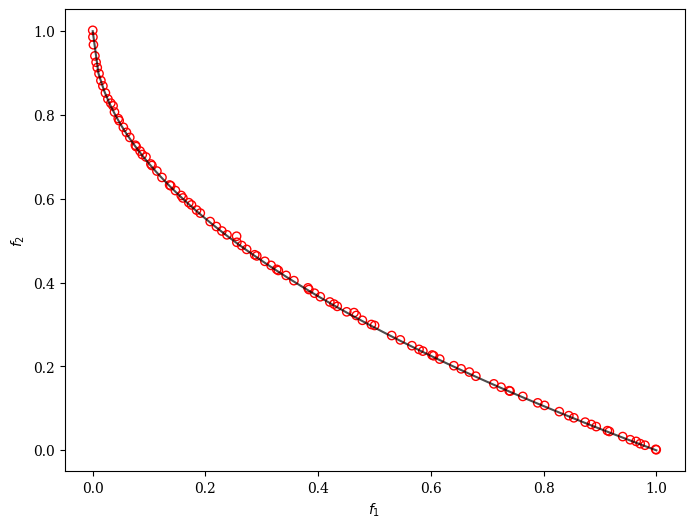

In [118]:
# tutorial from https://pymoo.org/algorithms/moo/nsga2.html
problem = get_problem("zdt1")
algorithm = NSGA2(pop_size=100)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [99]:
# 
labels_y_to_predict = ["emission_avg_last_five_years", "technical_cost"]
X = df_train[labels_x].to_numpy()
Y = df_train[labels_y_to_predict].to_numpy()





In [153]:
from pymoo.core.problem import ElementwiseProblem

class EmissionsProblem(ElementwiseProblem):
    """
    """
    
    def __init__(self,
        labels_x: Union[List, np.ndarray],
        labels_y: Union[List, np.ndarray],
        inds_obj: Union[List, np.ndarray, None] = None,
    ) -> None:


        ##  INIT AND CONVERSION
        
        labels_x = np.array(labels_x, )
        labels_y_universe = np.array(labels_y, )

        # filter indices used in the objective function
        inds_obj = (
            np.arange(labels_y_universe.shape[0])
            if inds_obj is None
            else np.array(inds_obj).astype(int)
        )
        labels_y = labels_y_universe[inds_obj]

        n = labels_x.shape[0]
        m = labels_y.shape[0]


        ##  PASS TO SUPER

        super().__init__(
            n_var = n,
            n_obj = m,
            n_ieq_constr = 0,
            xl = np.zeros(n),
            xu = np.ones(n),
        )


        ##  SET SOME PROPERTIES

        self.inds_obj = inds_obj
        self.labels_x = labels_x
        self.labels_y = labels_y
        self.labels_y_universe = labels_y_universe
        self.m = m                   # size of output feature space
        self.n = n                   # size of input feature space
        
        return None


    

    def _evaluate(self,
        x,
        out,
        *args, 
        **kwargs,
    ) -> None:
        """
        """
        # predict the outcome; both dimensions will be minimized
        arr = xgb_pipeline.predict(np.array([x]))
        vec = arr[0, self.inds_obj]
        out["F"] = vec

        return None


problem = EmissionsProblem(
    labels_x,
    labels_y,
    inds_obj = [1, 2],
)

In [154]:
problem.inds_obj

array([1, 2])

In [155]:
algorithm = NSGA2(
    pop_size = 40,
    n_offsprings = 10,
    sampling = FloatRandomSampling(),
    crossover = SBX(prob = 0.9, eta = 15),
    mutation = PM(eta = 20),
    eliminate_duplicates = True,
)

In [237]:
res = minimize(problem,
               algorithm,
               ('n_gen', 10000),
               #seed=1,
               verbose=False)

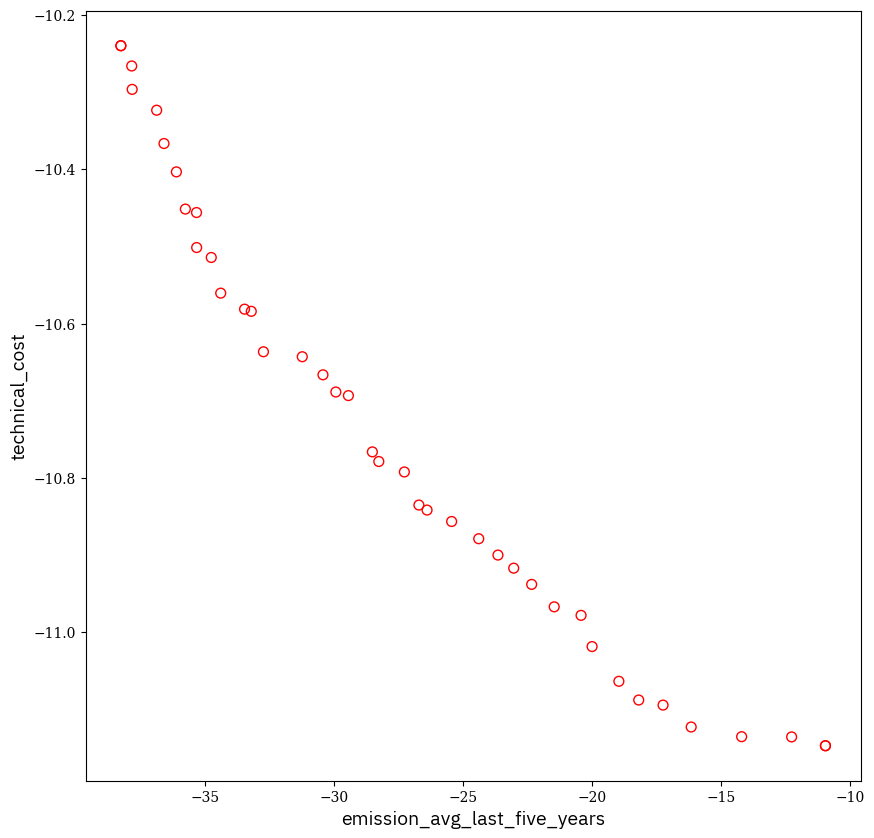

In [238]:
fig, ax = plt.subplots(figsize = (10, 10))

ax.set_xlabel(problem.labels_y[0], fontfamily = "IBM Plex Sans", fontsize = 14, )
ax.set_ylabel(problem.labels_y[1], fontfamily = "IBM Plex Sans", fontsize = 14, )

ax.scatter(
    res.F[:, 0], 
    res.F[:, 1], 
    facecolor = "none",
    edgecolor = "red",
    s = 50,
)

In [268]:
labels_y

['emission_total', 'emission_avg_last_five_years', 'technical_cost']

In [273]:
df_x = pd.DataFrame(res.X, columns = problem.labels_x)
df_y = pd.DataFrame(
    xgb_pipeline.predict(res.X),
    columns = problem.labels_y_universe,
)

df = (
    pd.concat(
        [
            df_x,
            df_y
        ],
        axis = 1,
    )
    .sort_values(by = ["emission_avg_last_five_years"], ascending = False, )
    .reset_index(drop = True, )
)

df["pareto_index"] = np.arange(df.shape[0])
df.to_csv(
    "/Users/usuario/Desktop/pareto_points_xgb_test_20250708.csv",
    index = None,
    encoding = "UTF-8"
)

In [275]:

df.iloc[0]


group_1_ef_lvst_entferm                                      0.935295
group_2_yf_agrc                                              0.455981
group_3_demscalar_soil                                       0.047607
group_4_demscalar_ippu                                       0.050904
group_5_efficfactor_enfu_industrial_energy_fuel              0.973715
group_6_elecfuelefficiency_trns                              0.167209
group_7_factor_waso_waste_per_capita_scalar_food             0.947579
group_8_frac_fgtv                                            0.977166
group_9_frac_agrc_agriculture_production_lost                0.000053
group_10_frac_agrc                                           0.314807
group_12_frac_enfu_transmission_loss_fuel_electricity        0.481611
group_13_frac_gnrl_eating_red_meats+                         0.763718
group_14_frac_ippu_cement_clinker                            0.123914
group_15_frac_ippu_production_with_co2_capture               0.992794
group_16_frac_lvst_m

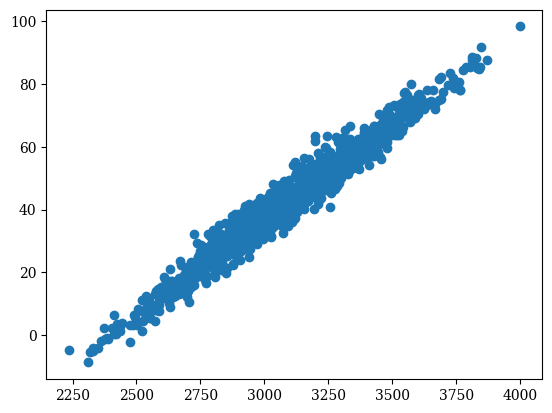

In [96]:
Y_filt = Y[
    (Y[:, 1] < 200)
    & (Y[:, 2] < 200)
]

plt.scatter(Y_filt[:, 0], Y_filt[:, 1])

In [160]:
problem.pareto_front()

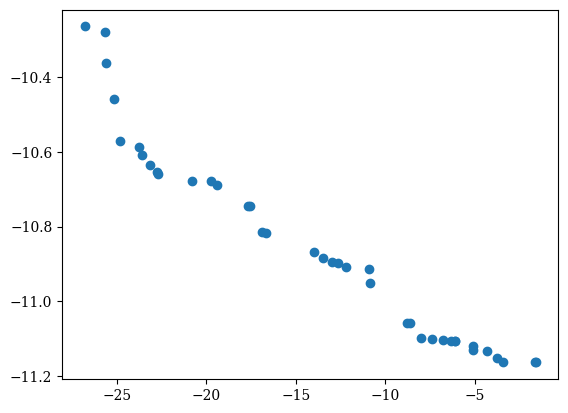